<a href="https://colab.research.google.com/github/pcmouadji-dot/deep_learning/blob/main/cifar10(ann_vs_cnn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
(train_images, train_labels), (test_images, test_labels) =tf.keras.datasets.cifar10.load_data()


array([[[179, 118,  83],
        [139,  96,  61],
        [ 77,  49,  26],
        ...,
        [ 87,  53,  46],
        [ 76,  47,  41],
        [ 77,  47,  41]],

       [[184, 130,  97],
        [133,  88,  53],
        [128,  89,  58],
        ...,
        [ 98,  61,  53],
        [ 91,  58,  51],
        [ 90,  57,  49]],

       [[180, 132, 100],
        [152, 104,  71],
        [176, 129,  92],
        ...,
        [101,  62,  53],
        [ 93,  56,  47],
        [ 95,  57,  49]],

       ...,

       [[142,  73,  61],
        [149,  84,  75],
        [144,  81,  73],
        ...,
        [119,  68,  56],
        [139,  87,  78],
        [159, 100,  89]],

       [[152,  83,  70],
        [166,  96,  81],
        [179, 106,  90],
        ...,
        [131,  77,  65],
        [144,  87,  77],
        [153,  90,  79]],

       [[159,  92,  79],
        [178, 107,  93],
        [183, 113,  95],
        ...,
        [150,  90,  76],
        [153,  91,  79],
        [152,  87,  73]]], dtype=uint8)
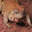

In [16]:
test_images[5]

In [17]:
train_images=train_images/255.0
test_images=test_images/255.0
train_labels=keras.utils.to_categorical(train_labels,num_classes=10)
test_labels=keras.utils.to_categorical(test_labels,num_classes=10)

In [18]:
train_labels[0:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [19]:
#this is the cnn model

model=keras.Sequential([
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation="relu"),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(3000,activation="relu"),

    keras.layers.Dense(10,activation="softmax"),
])
model.compile(optimizer="SGD",loss="categorical_crossentropy",metrics=["accuracy"])
model.fit(train_images,train_labels,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3025 - loss: 1.9387
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4514 - loss: 1.5376
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5156 - loss: 1.3709
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5584 - loss: 1.2554
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5953 - loss: 1.1598
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6261 - loss: 1.0709
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6558 - loss: 0.9930
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6822 - loss: 0.9197
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7080 - loss: 0.8478
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7320 - loss: 0.7782


frog
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
frog
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


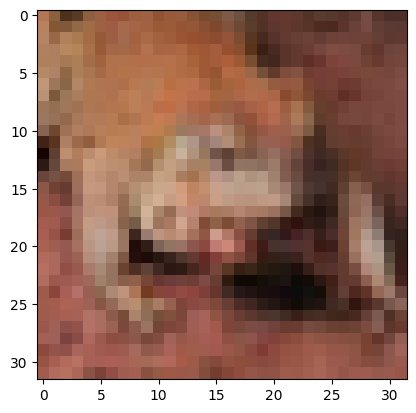

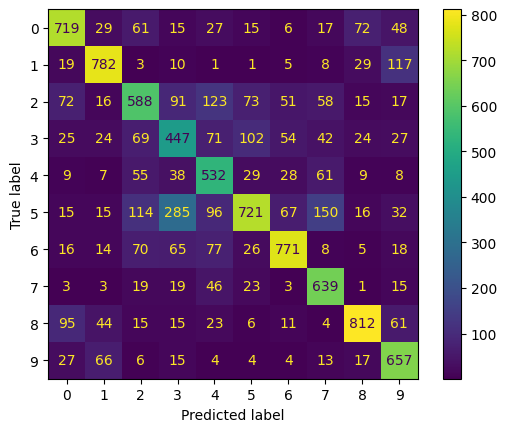

In [20]:
#for the cnn model

import numpy as np
plt.imshow(test_images[5])
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print(classes[np.argmax(test_labels[4])])
print(classes[np.argmax(model.predict(test_images)[5])])
prediction=model.predict(test_images)
prediction=np.argmax(prediction,axis=1)
test_labels=np.argmax(test_labels, axis=1)
cmd=ConfusionMatrixDisplay.from_predictions(prediction,test_labels)
plt.show()

In [21]:
# this is the ann model
ann_model=keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),

    keras.layers.Dense(3000,activation="relu"),
    keras.layers.Dense(1000,activation="relu"),

    keras.layers.Dense(10,activation="softmax"),
])

ann_model.compile(optimizer="SGD",loss="categorical_crossentropy",metrics=["accuracy"])
ann_model.fit(train_images,train_labels,epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3512 - loss: 1.8154
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4284 - loss: 1.6239
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4566 - loss: 1.5407
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4789 - loss: 1.4797
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4961 - loss: 1.4299
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5117 - loss: 1.3862
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5297 - loss: 1.3481
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5377 - loss: 1.3147
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5486 - loss: 1.2817
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5615 - loss: 1.2524


airplane
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
frog
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


AxisError: axis 1 is out of bounds for array of dimension 1

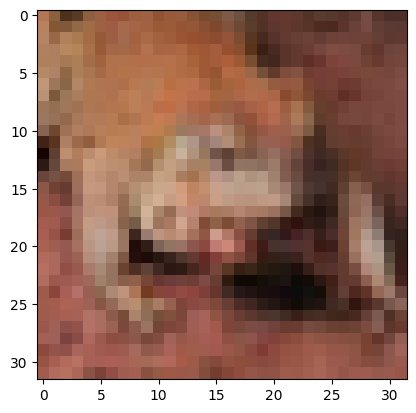

In [22]:
#for the ann model
import numpy as np
plt.imshow(test_images[5])
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print(classes[np.argmax(test_labels[4])])
print(classes[np.argmax(model.predict(test_images)[5])])
prediction=model.predict(test_images)
prediction=np.argmax(prediction,axis=1)
test_labels=np.argmax(test_labels, axis=1)
cmd=ConfusionMatrixDisplay.from_predictions(prediction,test_labels)
plt.show()